<a href="https://colab.research.google.com/github/Pragati-cloud/Data-Science-Machine-Learning-Deep-Learning-NLP-By-KrishNaik/blob/main/Multi_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [3]:
df_index = pd.read_csv("economic_index.csv")

In [4]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [ ]:
df_index.drop(columns=["Unnamed: 0","year","month"],axis=1, inplace =True)

In [13]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [14]:
df_index.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


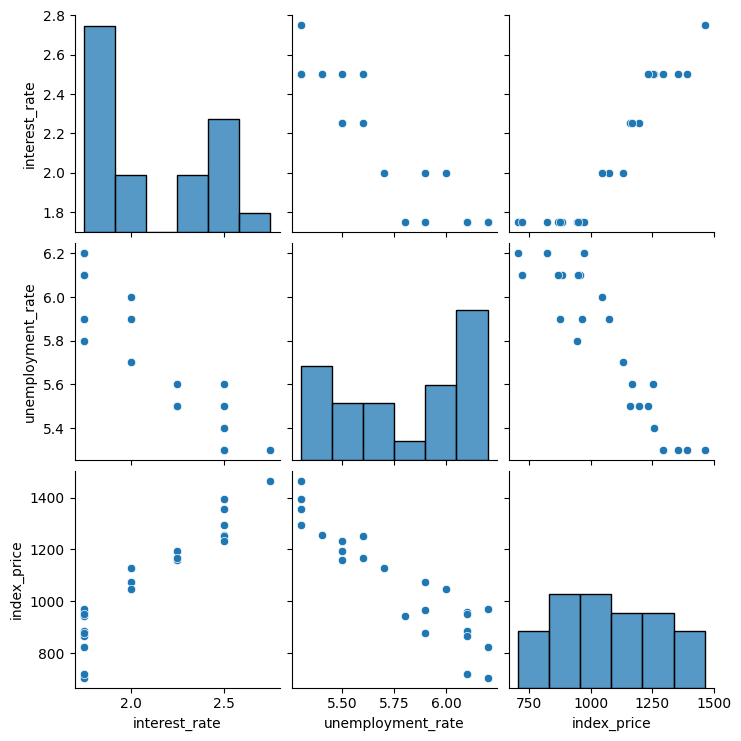

In [15]:
#visualization
sns.pairplot(df_index)

In [16]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [22]:
X=  df_index.iloc[:,:-1]   #df_index[['interest_rate','unemployement_rate']]
y= df_index['index_price']                          #df_index.iloc[:,-1]

In [23]:
#train test split
from sklearn.model_selection import train_test_split
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.25)

<Axes: xlabel='interest_rate', ylabel='index_price'>

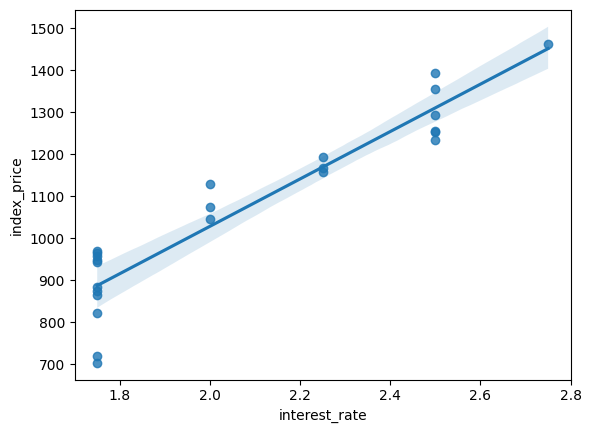

In [24]:
sns.regplot(x="interest_rate",y="index_price",data=df_index)

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

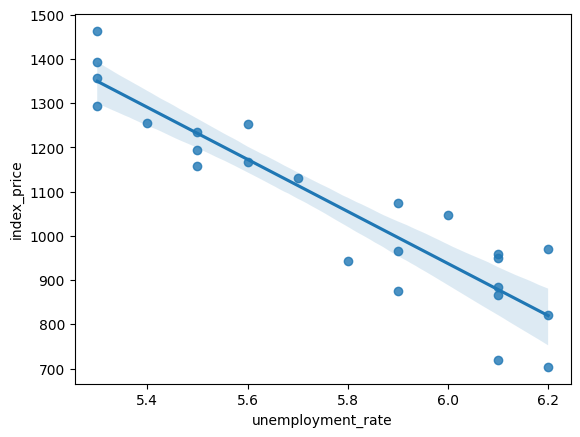

In [25]:
sns.regplot(x="unemployment_rate",y="index_price",data=df_index)

<Axes: xlabel='unemployment_rate', ylabel='interest_rate'>

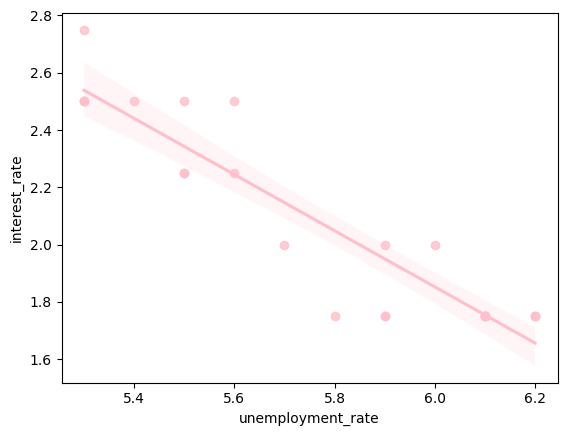

In [27]:
sns.regplot(x="unemployment_rate",y="interest_rate",data=df_index,color= 'pink')

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [29]:
X_train

array([[-0.96107446,  1.06155636],
       [-0.96107446,  1.38542101],
       [ 1.39792649, -1.52936086],
       [-0.96107446,  1.38542101],
       [-0.17474081,  0.73769171],
       [ 1.39792649, -1.52936086],
       [ 0.61159284, -0.88163155],
       [-0.96107446,  0.41382706],
       [ 0.61159284, -0.88163155],
       [ 1.39792649, -0.88163155],
       [-0.96107446,  1.06155636],
       [ 1.39792649, -0.5577669 ],
       [-0.96107446,  0.0899624 ],
       [-0.17474081,  0.41382706],
       [-0.96107446,  0.41382706],
       [ 1.39792649, -1.52936086],
       [-0.17474081, -0.23390225],
       [-0.96107446,  1.06155636]])

In [30]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [32]:
y_pred= model.predict(X_test)

In [33]:
#performance metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


mse= mean_squared_error(y_test, y_pred)
mae= mean_absolute_error(y_test,y_pred)
r2= r2_score(y_test, y_pred)
print(mse)
print(mae)
print(r2)


6180.5259229466465
55.32709295729004
0.9091920036233261


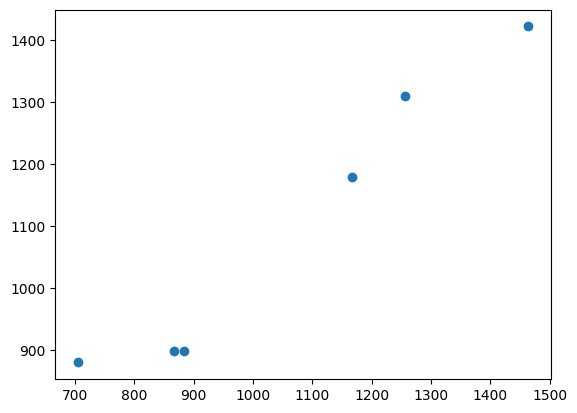

In [34]:
#assumption
plt.scatter(y_test, y_pred)

/tmp/ipython-input-3551394746.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals)


<Axes: xlabel='index_price', ylabel='Density'>

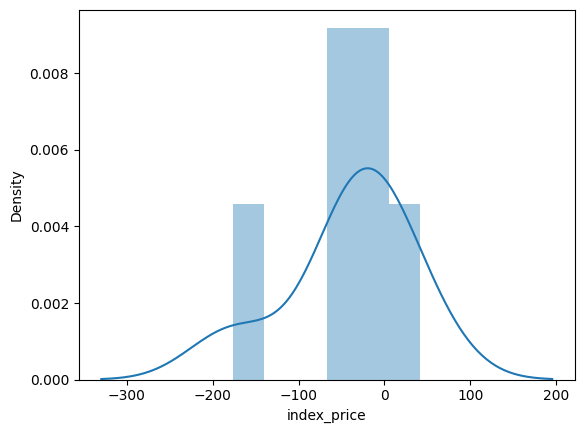

In [38]:
residuals = y_test - y_pred
sns.distplot(residuals)

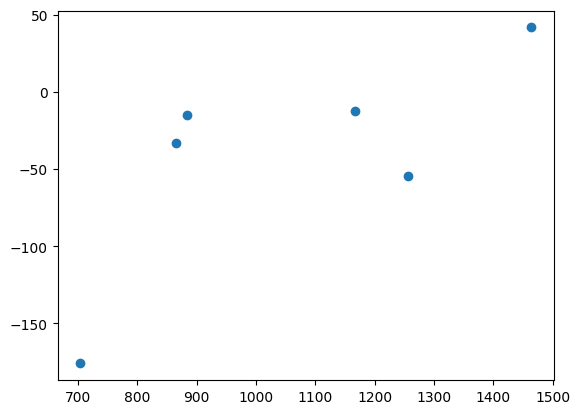

In [39]:
plt.scatter(y_test, residuals)